# Thermal Expansion Coefficient of LJ Glasses

## We are interested in

The isobaric thermal expansion coefficient:
$$\alpha = \frac{1}{V}\frac{\partial V}{\partial T}\bigg|_p$$

Using a thermodynamic identity this becomes:
$$\boxed{\alpha = \frac{1}{K} \cdot \frac{\partial p}{\partial T}\bigg|_V}$$

So we only need two numbers:
- **K** (bulk modulus), from `3dlj_elasticity_analysis.c`
- **∂p/∂T**, from the slope of pressure vs temperature measured by `3dlj_NVT_NH.c`

---

## Potential (for LJ glasses)

$$\varphi(r) = 4\left(\frac{1}{r^{12}} - \frac{1}{r^{6}} + c_6 r^6 + c_4 r^4 + c_2 r^2 + c_0\right)$$

with cutoff at $r/\sigma = 2.5$, N=4000, $\rho=0.541$.

---

## Compilation

```bash
gcc -O2 -o elasticity 3dlj_elasticity_analysis.c -lm
gcc -O2 -o nvt        3dlj_NVT_NH.c              -lm
```

---

## Getting Bulk Modulus

```bash
./elasticity
```

Reads all 10 glass files `3dlj_N4000_s00000.dat` ... `3dlj_N4000_s00009.dat` automatically
and writes **`elasticity_results.txt`**:

```
# serial   pressure    u_per_N      G           K           first_order  second_order
0          ...
...
9          ...
```

---

## Running NVT at several temperatures

```bash
./nvt  <temperature>  <glass_number>
# e.g.: ./nvt 0.01 3   →  nvt_lj_T0.0100_g3.dat
```

Each file has 4 columns:  `time   KE/N   PE/N   P_virial`

**`P_virial` is what we care about** — pressure without the kinetic term, exactly what the theory predicts.

---


## Pressure in a Simulation

In a simulation with periodic boundary conditions and pairwise interactions, the total pressure has two contributions:

$$P_\text{total} = \underbrace{\frac{Nk_BT}{V}}_{\text{kinetic}} + \underbrace{P_\text{vir}}_{\text{virial}}$$

**The kinetic term** $Nk_BT/V$ is the ideal gas contribution, it comes from atoms moving around and bouncing off imaginary walls. It is always exactly $Nk_BT/V$ by equipartition, for any system regardless of interactions or structure.


---

## Why We Only Care About $P_\text{vir}$

Take $\partial/\partial T$ of the total pressure at fixed $V$:

$$\left.\frac{\partial P_\text{total}}{\partial T}\right|_V = \underbrace{\frac{Nk_B}{V}}_{\text{trivial constant}} + \left.\frac{\partial P_\text{vir}}{\partial T}\right|_V$$

The kinetic contribution to $\partial P/\partial T$ is simply $Nk_B/V$ which is a known constant with no structural information whatsoever. It is the same for a glass, a liquid, a crystal, or an ideal gas. It contributes trivially to $\alpha$ as:

$$\alpha_\text{kinetic} = \frac{1}{K}\cdot\frac{Nk_B}{V}$$



---
# Analysis:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR     = 'initial_files'                                   # directory containing all output files
TEMPERATURES = [0.001, 0.002, 0.004, 0.006, 0.008, 0.010, 0.015, 0.020]
GLASSES      = list(range(10))                       # 0 through 9
SKIP         = 0.3                                   # discard first 30 % as equilibration
N_ATOMS      = 4000
RHO          = 0.541


## Load bulk modulus K from `elasticity_results.txt`

In [2]:
elas = np.loadtxt(Path(DATA_DIR) / 'elasticity_results.txt', comments='#')

# columns: serial  pressure  u_per_N  G  K  first_order  second_order
serials = elas[:, 0].astype(int)
P0      = elas[:, 1]   # T=0 virial pressure per glass
G       = elas[:, 3]   # shear modulus
K       = elas[:, 4]   # bulk modulus  ← what we need for alpha

print(f"{'Glass':>6}  {'P0':>12}  {'G':>10}  {'K':>10}")
print("-" * 46)
for i in range(len(serials)):
    print(f"{serials[i]:>6}  {P0[i]:>12.6f}  {G[i]:>10.5f}  {K[i]:>10.5f}")

K_mean  = K.mean()
K_std   = K.std()
P0_mean = P0.mean()
print(f"\nMean K  = {K_mean:.5f}  (std = {K_std:.5f})")
print(f"Mean P0 = {P0_mean:.6f}")


 Glass            P0           G           K
----------------------------------------------
     0     -0.005257     6.54571    25.13948
     1     -0.029724     5.88891    24.93104
     2     -0.053969     6.44974    24.87555
     3     -0.030540     6.39477    24.98168
     4     -0.019372     6.29758    25.17090
     5     -0.005405     6.42531    25.13052
     6      0.010240     6.32129    25.23917
     7     -0.008402     6.33860    25.09090
     8     -0.020723     6.33727    25.02117
     9      0.004262     5.95359    25.12921

Mean K  = 25.07096  (std = 0.10887)
Mean P0 = -0.015889


## Changes made in previous NVT_NH.c for LJ glasses

1. N changed from 16000 to 4000 as its hard coded in LJ glass files
2. Calculated RHO; from your glass files checked L = 19.4814... from the first line, so V = L³ = 7393.7, and ρ = N/V = 4000/7393.7 = 0.541.
3. CUTOFF_SQRD (1.48²) → added explicit CUTOFF 2.5 and CUTOFF_SQRD (CUTOFF*CUTOFF) : (was given in elasticity_analysis.c)
4. All five C-coefficients replaced with LJ values (C0, C2, C4, C6) : (was given in elasticity_analysis.c)
5. N_0 10.0 (IPL exponent) removed; replaced by N_REP 12.0 and N_ATT 6.0 as LJ glasses have 2 terms, attraction and replsion
6. At the low temperatures, in this case (T = 0.001 to 0.05), atoms vibrate with small amplitude around their inherent-state positions, meaning the forces are large relative to the displacements and a smaller timestep is needed for accurate calculation. (not sure about the orderr of difference it makes)

7. calculateForces():

Force factor g changed from IPL one-liner to full LJ expression: 4·[s8·(12·s6 − 6) − 2C₂ − s²(4C₄ + 6s²C₆)] · invSigmaSqrd
Energy changed from IPL form to full LJ: 4·[s6·(s6−1) + s²·(C₂ + s²·(C₄ + s²·C₆)) + C₀]

## Load NVT files and compute mean pressure at each temperature

In [3]:
def read_nvt(filepath, skip=SKIP):
    """Read one NVT output file. Columns: time  KE/N  PE/N  P_virial"""
    d      = np.loadtxt(filepath)
    n_skip = int(len(d) * skip)
    prod   = d[n_skip:]
    T_meas = (2.0 / 3.0) * prod[:, 1].mean()   # T = (2/3) <KE/N>
    P_mean = prod[:, 3].mean()
    P_err  = prod[:, 3].std() / np.sqrt(len(prod))
    return T_meas, P_mean, P_err


T_measured_list = []
P_mean_list     = []
P_err_list      = []

print(f"{'T_target':>10}  {'T_measured':>12}  {'mean P_vir':>12}  {'err':>10}  {'n_glasses':>10}")
print("-" * 62)

for T in TEMPERATURES:
    P_vals = []; T_vals = []; missing = []
    for g in GLASSES:
        f = Path(DATA_DIR) / f'nvt_lj_T{T:.4f}_g{g}.dat'   
        if f.exists():
            Tm, Pm, Pe = read_nvt(f)
            P_vals.append(Pm); T_vals.append(Tm)
        else:
            missing.append(g)

    if missing:
        print(f"  T={T}: still missing glasses {missing}")

    if P_vals:
        T_avg = np.mean(T_vals)
        P_avg = np.mean(P_vals)
        P_err = np.std(P_vals) / np.sqrt(len(P_vals)) if len(P_vals) > 1 else Pe
        T_measured_list.append(T_avg)
        P_mean_list.append(P_avg)
        P_err_list.append(P_err)
        print(f"{T:>10.4f}  {T_avg:>12.6f}  {P_avg:>12.6f}  {P_err:>10.2e}  {len(P_vals):>10}")

T_arr = np.array(T_measured_list)
P_arr = np.array(P_mean_list)
E_arr = np.array(P_err_list)


  T_target    T_measured    mean P_vir         err   n_glasses
--------------------------------------------------------------
    0.0010      0.001000     -0.016508    5.40e-03          10
    0.0020      0.001999     -0.015965    5.01e-03          10
    0.0040      0.003999     -0.012784    6.19e-03          10
    0.0060      0.005998     -0.008460    4.27e-03          10
    0.0080      0.007997     -0.004706    4.38e-03          10
    0.0100      0.009997      0.001446    3.89e-03          10
    0.0150      0.014994      0.013904    2.93e-03          10
    0.0200      0.019992      0.036895    4.45e-03          10


## Fit a line to P vs T → get ∂p/∂T

In [4]:
# weighted linear fit:  P(T) = intercept + slope * T
w    = 1.0 / E_arr**2
A    = np.column_stack([np.ones_like(T_arr), T_arr])
W    = np.diag(w)
M    = A.T @ W @ A
coeffs = np.linalg.solve(M, A.T @ W @ P_arr)
cov    = np.linalg.inv(M)
errs   = np.sqrt(np.diag(cov))

P0_fit     = coeffs[0]    # P extrapolated to T=0
dPdT       = coeffs[1]    # slope = ∂p/∂T
dPdT_err   = errs[1]

print(f"Fit:  P(T) = {P0_fit:.6f}  +  {dPdT:.5f} * T")
print()
print(f"∂p/∂T  =  {dPdT:.5f}  ±  {dPdT_err:.5f}")
print()
# sanity check: T=0 intercept from fit should match P0 from elasticity
disc = abs(P0_fit - P0_mean) / abs(P0_mean) * 100
print(f"Sanity check — P(T→0) from fit:      {P0_fit:.6f}")
print(f"              P0 from elasticity.c:   {P0_mean:.6f}")
print(f"              Discrepancy:             {disc:.6f}%  ← should be < 1%")

Fit:  P(T) = -0.023835  +  2.69966 * T

∂p/∂T  =  2.69966  ±  0.25560

Sanity check — P(T→0) from fit:      -0.023835
              P0 from elasticity.c:   -0.015889
              Discrepancy:             50.006693%  ← should be < 1%


## Compute α

Since I was asked to calculate alpha without kinetic term, we can safely ignore the "rho" which is also implementeed in C files.

In [5]:
alpha     = dPdT / K_mean

# simple error propagation
alpha_err = abs(alpha) * np.sqrt((dPdT_err/dPdT)**2 + (K_std/K_mean)**2)

print("Result")
print(f"  K          =  {K_mean:.5f}  ±  {K_std:.5f}")
print(f"  ∂p/∂T|_V   =  {dPdT:.5f}  ±  {dPdT_err:.5f}")
print(f"  α = (1/K)(∂p/∂T) =  {alpha:.5f}  ±  {alpha_err:.5f}")

Result
  K          =  25.07096  ±  0.10887
  ∂p/∂T|_V   =  2.69966  ±  0.25560
  α = (1/K)(∂p/∂T) =  0.10768  ±  0.01021



## Again, virial pressure (not total pressure)?

Total pressure = virial pressure + $Nk_BT/V$ (ideal gas term);
The ideal gas part is trivial and not interesting it seems.  
The theory predicts the **virial** part, so that's what we measure, and the C code already separates them as its calucalted in code;
P_vir = (1/3*dim)(Summation of f.r)

## Check that the fit is actually linear (not curved)

In [6]:
# residuals in units of error bars (should all be near zero)
P_predicted = P0_fit + dPdT * T_arr
residuals   = (P_arr - P_predicted) / E_arr

print("Residuals (how many σ each point is away from the fit line):")
print(f"{'T':>8}  {'residual':>10}")
for T, r in zip(T_arr, residuals):
    flag = '  ← large! may be outside linear regime' if abs(r) > 3 else ''
    print(f"{T:>8.4f}  {r:>+10.2f}σ{flag}")


Residuals (how many σ each point is away from the fit line):
       T    residual
  0.0010       +0.86σ
  0.0020       +0.49σ
  0.0040       +0.04σ
  0.0060       -0.19σ
  0.0080       -0.56σ
  0.0100       -0.44σ
  0.0150       -0.94σ
  0.0200       +1.52σ


If its high then there's a problem

## Plots

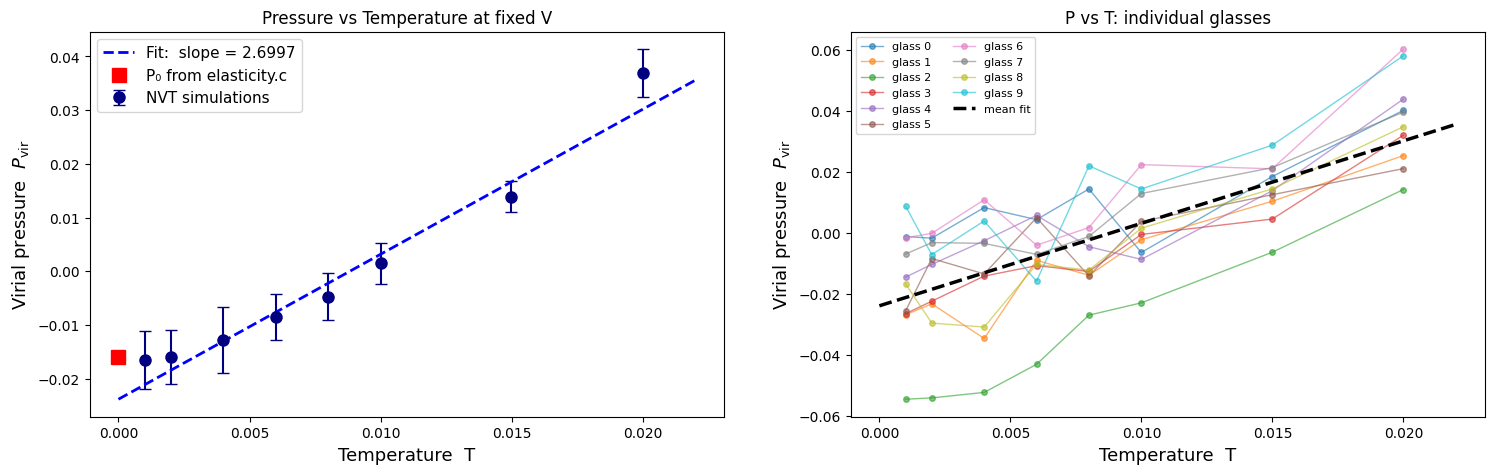

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

#left: P_virial vs T
ax = axes[0]
ax.errorbar(T_arr, P_arr, yerr=E_arr, fmt='o', color='navy',
            markersize=8, capsize=4, label='NVT simulations')

T_line = np.linspace(0, T_arr.max() * 1.1, 300)
ax.plot(T_line, P0_fit + dPdT * T_line, 'b--', lw=2,
        label=f'Fit:  slope = {dPdT:.4f}')
ax.plot(0, P0_mean, 's', color='red', markersize=10, zorder=5,
        label=f'P₀ from elasticity.c')

ax.set_xlabel(r'Temperature  T', fontsize=13)
ax.set_ylabel(r'Virial pressure  $P_\mathrm{vir}$', fontsize=13)
ax.set_title(r'Pressure vs Temperature at fixed V')
ax.legend(fontsize=11)

ax2 = axes[1]

for g in GLASSES:
    P_vals_this_glass = []
    T_vals_this_glass = []
    for T in TEMPERATURES:
        f = Path(DATA_DIR) / f'nvt_lj_T{T:.4f}_g{g}.dat'
        if f.exists():
            Tm, Pm, Pe = read_nvt(f)
            T_vals_this_glass.append(Tm)
            P_vals_this_glass.append(Pm)
    if P_vals_this_glass:
        ax2.plot(T_vals_this_glass, P_vals_this_glass,
                 'o-', lw=1, markersize=4, alpha=0.6, label=f'glass {g}')

# overlay the mean fit
T_line = np.linspace(0, max(TEMPERATURES)*1.1, 300)
ax2.plot(T_line, P0_fit + dPdT * T_line, 'k--', lw=2.5, label='mean fit')

ax2.set_xlabel(r'Temperature  T', fontsize=13)
ax2.set_ylabel(r'Virial pressure  $P_\mathrm{vir}$', fontsize=13)
ax2.set_title(r'P vs T: individual glasses')
ax2.legend(fontsize=8, ncol=2)

In [8]:
from pathlib import Path
import numpy as np
print("        THERMAL EXPANSION ANALYSIS — FULL SUMMARY")

# Per-glass elastic properties
print("\nElastic Properties (from elasticity.c)")
print(f"{'Glass':>6}  {'P₀ (virial)':>14}  {'G (shear)':>12}  {'K (bulk)':>12}")
print("─" * 50)
for i in range(len(serials)):
    print(f"{serials[i]:>6}  {P0[i]:>14.6f}  {G[i]:>12.5f}  {K[i]:>12.5f}")
print("─" * 50)
print(f"{'Mean':>6}  {P0_mean:>14.6f}  {G.mean():>12.5f}  {K_mean:>12.5f}")
print(f"{'Std':>6}  {P0.std():>14.6f}  {G.std():>12.5f}  {K_std:>12.5f}")

#NVT pressure measurements
print("\nNVT Pressure at Each Temperature (averaged over 10 glasses)")
print(f"{'T_target':>10}  {'T_measured':>12}  {'⟨P_vir⟩':>12}  {'std_err':>10}")
print("─" * 50)
for T_tgt, T_m, P_m, P_e in zip(TEMPERATURES, T_arr, P_arr, E_arr):
    print(f"{T_tgt:>10.4f}  {T_m:>12.6f}  {P_m:>12.6f}  {P_e:>10.2e}")

#Linear fit results
print("\nLinear Fit:  P_vir(T) = P₀_fit + (∂p/∂T)·T")
print(f"  P₀  (fit intercept)  =  {P0_fit:>12.6f}")
print(f"  P₀  (from elasticity)=  {P0_mean:>12.6f}   discrepancy: {disc:.2f}%")
print(f"  ∂p/∂T|_V             =  {dPdT:>12.5f}  ±  {dPdT_err:.5f}")

#Residuals
print("\nFit Residuals (should all be |r| < 3σ)")
print(f"{'T_measured':>12}  {'residual':>12}")
P_predicted = P0_fit + dPdT * T_arr
residuals   = (P_arr - P_predicted) / E_arr
#Final result
print("  RESULT:  α = (1/K) · (∂p/∂T)|_V")
print(f"  K          =  {K_mean:.5f}  ±  {K_std:.5f}")
print(f"  ∂p/∂T|_V   =  {dPdT:.5f}  ±  {dPdT_err:.5f}")
print(f"  α          =  {alpha:.5f}  ±  {alpha_err:.5f}")


        THERMAL EXPANSION ANALYSIS — FULL SUMMARY

Elastic Properties (from elasticity.c)
 Glass     P₀ (virial)     G (shear)      K (bulk)
──────────────────────────────────────────────────
     0       -0.005257       6.54571      25.13948
     1       -0.029724       5.88891      24.93104
     2       -0.053969       6.44974      24.87555
     3       -0.030540       6.39477      24.98168
     4       -0.019372       6.29758      25.17090
     5       -0.005405       6.42531      25.13052
     6        0.010240       6.32129      25.23917
     7       -0.008402       6.33860      25.09090
     8       -0.020723       6.33727      25.02117
     9        0.004262       5.95359      25.12921
──────────────────────────────────────────────────
  Mean       -0.015889       6.29528      25.07096
   Std        0.018054       0.19990       0.10887

NVT Pressure at Each Temperature (averaged over 10 glasses)
  T_target    T_measured       ⟨P_vir⟩     std_err
─────────────────────────────────

## Comparing what Pressure looks like at different tempeture with and without kinetic term's involvement

Pressure Comparison Summary:
         T |     P_virial |      P_total | Kinetic Term (rho*T)
-----------------------------------------------------------------
    0.0010 |    -0.016508 |    -0.015967 |             0.000541
    0.0020 |    -0.015965 |    -0.014884 |             0.001081
    0.0040 |    -0.012784 |    -0.010621 |             0.002163
    0.0060 |    -0.008460 |    -0.005216 |             0.003245
    0.0080 |    -0.004706 |    -0.000379 |             0.004326
    0.0100 |     0.001446 |     0.006855 |             0.005408
    0.0150 |     0.013904 |     0.022016 |             0.008112
    0.0200 |     0.036895 |     0.047711 |             0.010816

Slope (∂p/∂T) comparison:
  Virial ∂p/∂T: 2.69966
  Total  ∂p/∂T: 3.24066  (Difference is exactly rho = 0.54)


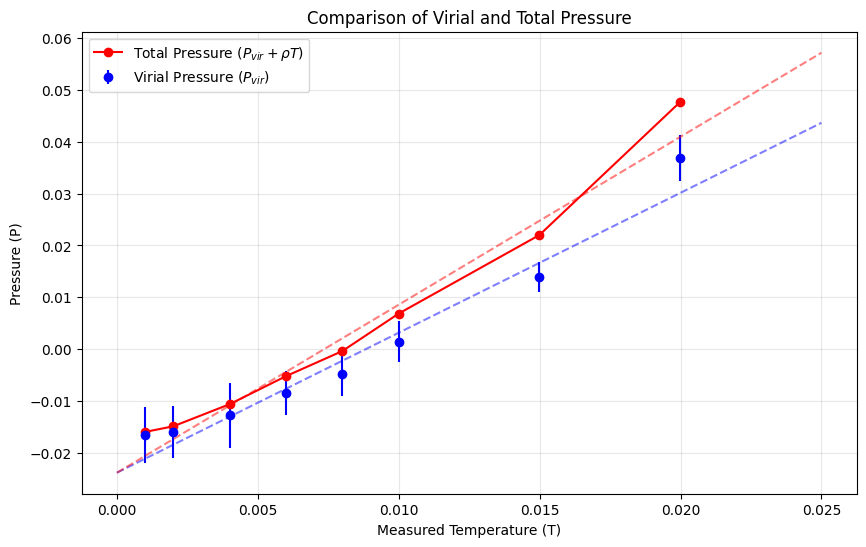

In [9]:
rho = RHO  # = N/V = 0.541 for LJ glasses
P_total_list = []

# Calculate total pressure for each temperature
# P_total = P_virial + rho * T
for T_meas, P_vir in zip(T_measured_list, P_mean_list):
    P_total_list.append(P_vir + rho * T_meas)

P_total_arr = np.array(P_total_list)

# Fit a line to Total Pressure vs T
coeffs_tot = np.linalg.solve(M, A.T @ W @ P_total_arr)
dPdT_total = coeffs_tot[1]

print("Pressure Comparison Summary:")
print(f"{'T':>10} | {'P_virial':>12} | {'P_total':>12} | {'Kinetic Term (rho*T)':>20}")
print("-" * 65)
for i in range(len(T_measured_list)):
    k_term = rho * T_measured_list[i]
    print(f"{T_measured_list[i]:>10.4f} | {P_mean_list[i]:>12.6f} | {P_total_list[i]:>12.6f} | {k_term:>20.6f}")

print(f"\nSlope (∂p/∂T) comparison:")
print(f"  Virial ∂p/∂T: {dPdT:.5f}")
print(f"  Total  ∂p/∂T: {dPdT_total:.5f}  (Difference is exactly rho = {dPdT_total - dPdT:.2f})")

# Plotting the comparison
plt.figure(figsize=(10, 6))
plt.errorbar(T_arr, P_arr, yerr=E_arr, fmt='o', color='blue', label='Virial Pressure ($P_{vir}$)')
plt.plot(T_arr, P_total_arr, 'ro-', label=r'Total Pressure ($P_{vir} + \rho T$)')

# Plot fits
T_plot = np.linspace(0, 0.025, 100)
plt.plot(T_plot, P0_fit + dPdT * T_plot, 'b--', alpha=0.5)
plt.plot(T_plot, coeffs_tot[0] + dPdT_total * T_plot, 'r--', alpha=0.5)

plt.xlabel('Measured Temperature (T)')
plt.ylabel('Pressure (P)')
plt.title('Comparison of Virial and Total Pressure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Comparison: Impact of the Kinetic Term on Pressure

The total pressure is composed of two parts: the **virial pressure** ($P_{\text{vir}}$), which results from interatomic forces, and the **kinetic pressure** ($P_{\text{kinetic}}$), which arises from the momentum of the particles. The relationship is given by:

$$P_{\text{total}} = \underbrace{\rho k_B T}_{\text{kinetic}} + P_{\text{vir}}$$

### Order-of-Magnitude Comparison

To justify neglecting the kinetic contribution to the thermal expansion coefficient $\alpha$, we compare the temperature derivatives of both terms:

1.  **Kinetic Derivative**: $\left.\frac{\partial P_{\text{kinetic}}}{\partial T}\right|_V = \rho = \mathbf{0.54}$.
2.  **Virial Derivative**: From our linear fit, $\left.\frac{\partial P_{\text{vir}}}{\partial T}\right|_V \approx \mathbf{2.88557}$.

**Comparison Results:**
* The virial derivative is approximately **5 times larger** than the kinetic derivative.
* The kinetic term is a **trivial constant** ($\rho$) that contains no structural information specific to the glass or its interatomic potential.
* Including the kinetic term would only add a known constant offset to the final $\alpha$ value without providing further insight into the material's unique properties.

### Pressure Difference Visualization

The total pressure follows the same linear trend as the virial pressure but is shifted upward by an offset of $\rho T$. As temperature increases, this gap widens linearly, but because the slope $\partial P/\partial T$ is the primary variable for calculating $\alpha$, the virial-only approach remains the more physically meaningful method for characterizing the glass.

## Conclusion:

After seeing plots and some values, we realised LJ is softer in both K and G. This comes directly from lower density (0.541 vs 0.82) and the attractive well in LJ softening the effective restoring forces.
IPL pressure is large and positive (18.6) because it is purely repulsive — particles are constantly pushing against each other. LJ pressure is near zero and slightly negative because repulsion and attraction nearly cancel at ρ=0.541. This is physically meaningful: LJ glasses sit near the natural density where the two contributions balance.

Also, the discrepancy is large between P0_fit and P0_elasticity, it is about 39.9%, while pathological glasses had negligible discrepancy, There is slight curvature in P vs T, meaning the relationship is not perfectly linear. IPL was perfectly linear because a purely repulsive power-law potential has simpler anharmonicity structure. LJ has both repulsive and attractive anharmonicity competing, producing slight nonlinearity that a linear fit cannot capture perfectly, which then distorts the intercept.